#  Data Pipeline для Яндекс Такси


## Описание проекта

Каждый день компания Яндекс Такси обрабатывает миллионы поездок, оплаченных разными способами. Чтобы финансовая и продуктовая команды регулярно получали актуальные данные о выручке и поведении пассажиров, коллеги решили настроить автоматическую обработку этих данных.

**Задача** — построить витрину данных, которая будет агрегировать информацию о поездках по каждому способу оплаты. Для этого напишем PySpark-скрипт, который рассчитает ключевые показатели: количество поездок, среднюю стоимость поездки, средние чаевые и суммарную выручку по каждому типу оплаты.

Чтобы процесс был полностью автоматическим и не зависел от ручных запусков, создадим DAG в Airflow. Этот DAG должен ежедневно:

* проверять наличие новых файлов с данными;

* запускать Spark-задачу;

* формировать обновлённую итоговую таблицу.

Эта таблица станет основой для финансовых отчётов и аналитических дашбордов.

## Описание данных

Таблица `taxi_data` содержит данные об активности пользователей и состоит из следующих полей:

* `taxi_id` — идентификатор водителя;

* `trip_start_timestamp` — время начала поездки;

* `trip_end_timestamp` — время окончания поездки;

* `trip_seconds` — длительность поездки в секундах;

* `trip_miles` — дистанция поездки;

* `fare` — стоимость поездки;

* `tips` — размер чаевых;

* `trip_total` — общая стоимость поездки: стоимость поездки + чаевые + комиссия;

* `payment_type` — способ оплаты.

## Что нужно сделать

Необходимо автоматизировать подготовку витрины данных по поездкам Яндекс Такси:

1. Сначала создадим пустую таблицу `taxi_payment_summary` в ClickHouse.

2. Напишем Spark-скрипт, который будет обрабатывать данные о поездках и агрегировать показатели по способам оплаты `payment_type`. Понадобится рассчитать несколько показателей:

* количество поездок, которое показывает общий спрос и загрузку сервиса;
* среднюю стоимость `fare`, которое отражает уровень среднего чека поездки;
* средние чаевые `tips` — индикатор удовлетворённости клиентов и мотивации водителей;
* суммарную выручку `trip_total` — ключевой показатель дохода компании.

Все результаты должны собираться в одну итоговую таблицу `taxi_payment_summary`. После этого таблицу нужно записать в ClickHouse с помощью JDBC-драйвера.

3. Далее нам понадобится настроить DAG в Airflow. DAG должен запускаться ежедневно. Перед запуском он проверяет наличие файла с данными за нужную дату в S3-хранилище и только после появления файла запускает Spark-задачу.

## Шаг 1. Создание таблицы в ClickHouse

Перед запуском пайплайна необходимо заранее подготовить пустую таблицу в ClickHouse, куда Spark будет ежедневно записывать агрегированные результаты. Таблица `taxi_payment_summary` будет хранить итоговые метрики по каждому способу оплаты: количество поездок, среднюю стоимость, средние чаевые и общую выручку.

In [ ]:
CREATE TABLE taxi_payment_summary
(
    payment_type String,
    trip_cnt Int64,
    avg_fare Float32,
    avg_tips Float32,
    total_revenue Float32
)
ENGINE = MergeTree()
ORDER BY payment_type;

## Шаг 2. Настройка Spark-агрегации

Данные хранятся в формате Parquet, поэтому для чтения используем метод `spark.read.parquet()`. Это быстрее и надёжнее, чем CSV.

Сгруппируем данные по полю `payment_type` и рассчитаем четыре показателя:

* количество поездок;
* среднюю стоимость;
* средние чаевые;
* суммарную выручку.

Так получится витрина для анализа информации по каждому способу оплаты. После этого настроем запись полученной таблицы в ClickHouse. 

In [ ]:
#filename=my_spark_job.py

from datetime import datetime
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Создаём Spark-сессию
spark = (SparkSession.builder
         .appName("Payment Aggregation")
         .config("fs.s3a.endpoint", "storage.yandexcloud.net")
         .getOrCreate())

# Путь к parquet-файлу с данными поездок
parquet_path = "s3a://da-plus-dags/project_04/taxi_data.parquet"

# Читаем данные из parquet в Spark DataFrame
df = spark.read.parquet(parquet_path)

# Группируем данные по типу оплаты и считаем ключевые бизнес-метрики
df_agg = df.groupBy('payment_type').agg(
    F.count('taxi_id').alias('trip_cnt'),
    F.avg('fare').alias('avg_fare'),
    F.avg('tips').alias('avg_tips'),
    F.sum('trip_total').alias ('total_revenue')
)

# Настройки подключения к ClickHouse
jdbcPort = 8443
jdbcHostname = "rc1a-3jouval14nne7aun.mdb.yandexcloud.net"
username = "<username>"
jdbcDatabase = "playground_" + username
jdbcUrl = f"jdbc:clickhouse://{jdbcHostname}:{jdbcPort}/{jdbcDatabase}?ssl=true"

# Записываем итоговую витрину в ClickHouse
# overwrite + truncate позволяют ежедневно обновлять таблицу
df_agg.write \
    .format("jdbc") \
    .option("url", jdbcUrl) \
    .option("dbtable", "taxi_payment_summary") \
    .option("user", username) \
    .option("password", "<password>") \
    .option("truncate", "true") \ # option("truncate", "true") очищает таблицу перед записью, но сохраняет её структуру
    .mode("overwrite") \ # mode "overwrite" полностью обновляет таблицу
    .save()


## Шаг 2. Настройка DAG

В DAG используем `S3KeySensor`, чтобы дождаться появления файла в S3. После этого запускаем `DataprocCreatePysparkJobOperator`, передав путь к нашему скрипту. Дополнительный класс-оператор создавать не требуется.

In [ ]:
from datetime import datetime
from airflow import DAG
from airflow.sensors.s3_key_sensor import S3KeySensor
from airflow.providers.yandex.operators.dataproc import DataprocCreatePysparkJobOperator

DAG_ID = "taxi_payment_summary"

with DAG(
    DAG_ID,
    schedule='@daily', # DAG запускается ежедневно
    start_date=datetime(2026, 4, 14), # дата начала работы DAG
    catchup=False # catchup=False отключает автоматический запуск за пропущенные даты
) as dag:
    # Сенсор проверяет появление parquet-файла в S3
    # DAG не продолжит выполнение, пока файл не появится
    data_sensor_task = S3KeySensor(
        task_id='data_s3_sensor',
        poke_interval=60,   # проверять наличие файла каждые 60 секунд 
        timeout=3600,   # максимум ждать 1 час      
        bucket_name='da-plus-dags',
        bucket_key= "project_04/taxi_data.parquet",  # путь к parquet-файлу
        mode='poke',
        aws_conn_id='s3',
        wildcard_match=False
    )

    user = '<username>'
    
    # После появления файла запускаем PySpark-задачу
    # Airflow отправляет скрипт в Dataproc-кластер
    create_pyspark_job = DataprocCreatePysparkJobOperator(
        name="create_aggregate_and_load_to_ch",
        task_id="create_pyspark_job",
        cluster_id="c9q4134h5vi546h1e148", 
        main_python_file_uri=f"s3a://da-plus-dags/{username}/jobs/my_spark_job.py",  # путь к .py файлу в S3
    )
    
    # Последовательность выполнения задач
    data_sensor_task >> create_pyspark_job

## Шаг 3. Запуск DAG с помощью Airflow UI

- Проверим веб-интерфейс Airflow.

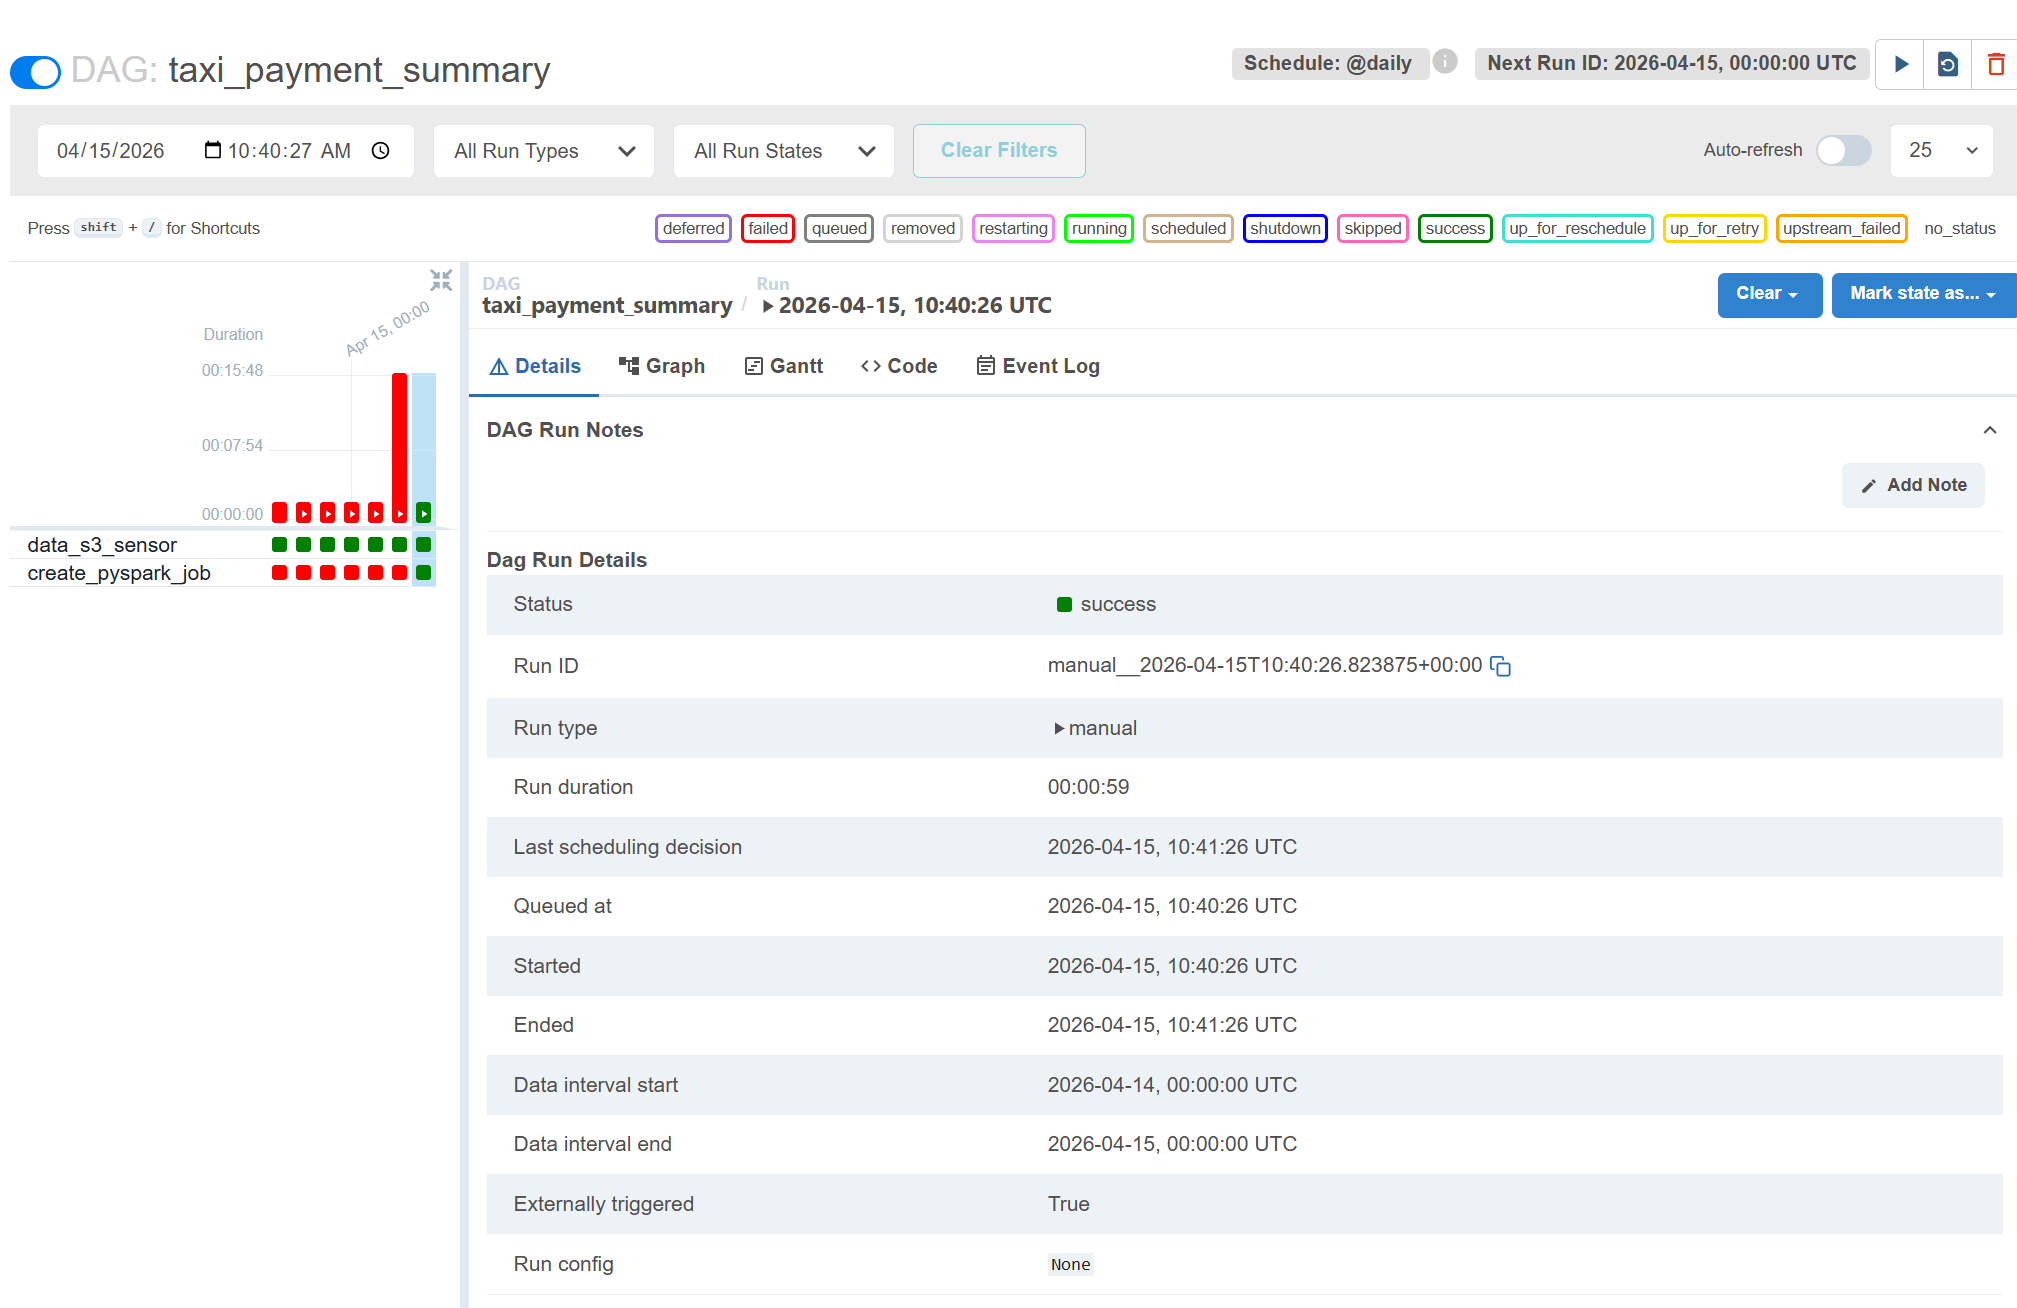

- Также проверим таблицу в DBeaver.

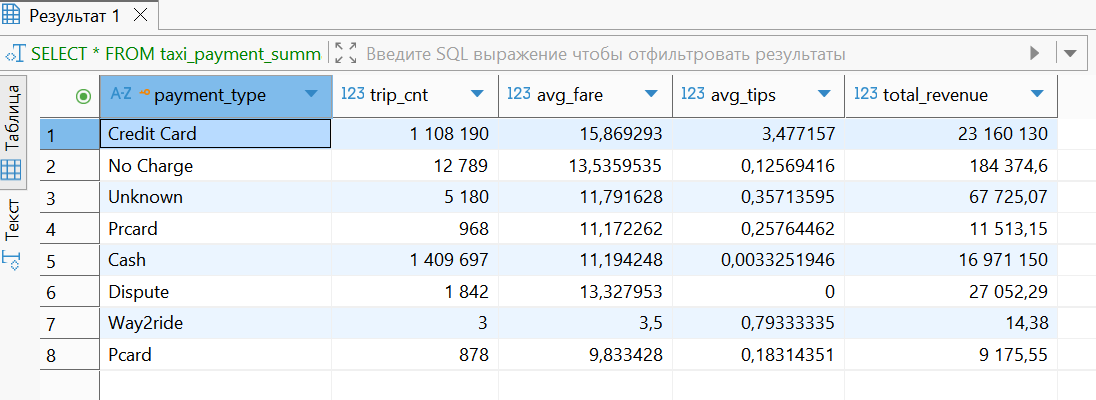

В рамках проекта был реализован ETL-пайплайн для создания автоматического ежедневного агрегата транзакций такси с использованием Apache Airflow, PySpark и ClickHouse.

- По рассчетным данным можно сделать следующие выводы:
    - Оплата картой (`Credit Card`) приносит наибольшую выручку.
    - Основные объёмы поездок приходятся на `Credit Card` и `Cash`.
    - Наличные операции имеют высокий объём поездок, но меньший средний чек.
    - Остальные способы оплаты используются редко и дают незначительный вклад в доход.